<hr>

# **Fase 1: Business Understanding**

Após as análises de cariz preditivo (Regressão e Classificação), este notebook dedica-se à **Aprendizagem Não-Supervisionada**. O objetivo principal muda de "prever um valor" para **compreender a estrutura interna** dos dados de estagiários, identificando perfis que não são visíveis através de análises lineares simples.

### 1. Objetivo de Negócio: Segmentação Estratégica

Nesta etapa, pretendemos dotar a equipa de **Recursos Humanos** de uma visão por segmentos (*Clusters*), permitindo:

- **Identificar Perfis de Talento**: Agrupar estagiários com comportamentos e características semelhantes (ex: alta performance vs. baixa assiduidade).  
- **Personalização de Planos de Carreira**: Criar estratégias de retenção e formação específicas para cada grupo identificado.  
- **Análise de Equidade**: Verificar se grupos com perfis de desempenho idênticos estão a ser remunerados de forma coerente (cruzando os clusters com os dados de *Salary* posteriormente).


### 2. O desafio do modelo Não Supervisionado consiste em:

- **Isolamento de Variáveis de Desfecho**: Para garantir um agrupamento imparcial, removemos o `Salary` e o `Retained` da fase de treino do modelo. 
    - O objetivo é agrupar estagiários pelo seu **comportamento e perfil**, e não pelo que ganham ou se ficaram na empresa. Isto permite-nos, posteriormente, analisar se a empresa premeia corretamente os perfis de alto valor.
- **Redução de Ruído**: Utilizar variáveis de perfil e performance para encontrar **distâncias matemáticas** (similaridades) entre indivíduos. 
- **Definição de K (Clusters)**: Aplicar métricas estatísticas (como o Método do Cotovelo) para determinar o número natural de grupos existentes.


### 3. Critérios de Sucesso

- **Técnico**: Obter grupos coesos (*baixa inércia intracluster*) e bem separados entre si, garantindo que cada cluster representa de facto um perfil distinto.  
- **Negócio**: Traduzir os clusters em **Perfis acionáveis** para o RH (ex: "O Estagiário de Alto Potencial", "O Perfil de Risco de Saída", etc.).

<hr>

# **Fase 2: Data Understanding**

Com base em análises exploratórias prévias, confirmamos que o dataset apresenta ausência de correlação linear significativa, zero valores nulos e ausência de outliers significativos. Assim, esta fase foca-se exclusivamente na geometria necessária para o K-Means.

### 1. Preparação para Clustering
- **Geometria das Variáveis:** Analisamos a amplitude de Age, Internship_Duration_Months, Supervisor_Evaluation e Attendance_%. Como o K-Means utiliza distância euclidiana, a discrepância de escalas entre estas variáveis exige Standardization (Z-score) para garantir que cada feature contribui equitativamente para a formação dos grupos.
- **Independência de Features:** A falta de correlação entre as 4 variáveis de treino é aqui vista como uma vantagem, pois indica que cada uma representa uma dimensão ortogonal e única do perfil do estagiário, maximizando a riqueza da segmentação.

### 2. Estratégia de Variáveis
- **Features de Treino (O Perfil):** Age, Internship_Duration_Months, Supervisor_Evaluation, Attendance_%.
- **Variáveis de Análise (Isoladas):** Salary e Retained.
- **Justificação de Negócio:** Estas variáveis são removidas do treino para garantir um agrupamento imparcial. O objetivo é agrupar por perfil comportamental e, posteriormente, analisar se a retenção e o salário são coerentes com os clusters identificados.

In [1]:
# Importar libraries

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
from pandas.plotting import parallel_coordinates
import plotly.express as px
from sklearn.decomposition import PCA


# Paths do projeto

BASE_DIR = Path().resolve()

FIGURES_DIR = BASE_DIR / "outputs" / "figures"
DATA_DIR = BASE_DIR / "data"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Carregar o dataset 

DATASET_PATH = BASE_DIR / "HR-Intern-Retention_Dataset.csv"

df_raw = pd.read_csv(DATASET_PATH)
df_raw.head()

,Intern_ID,Age,Major,Internship_Duration_Months,Department,Supervisor_Evaluation,Salary,Attendance_%,Retained
0,1,24,IT,20,Legal,1.8,1956,71.9,1
1,2,21,Law,15,HR,1.2,1687,82.7,0
2,3,28,Engineering,3,HR,1.7,926,79.0,0
3,4,25,IT,23,Marketing,2.1,1929,86.5,1
4,5,22,Engineering,8,Legal,1.7,1808,97.5,1


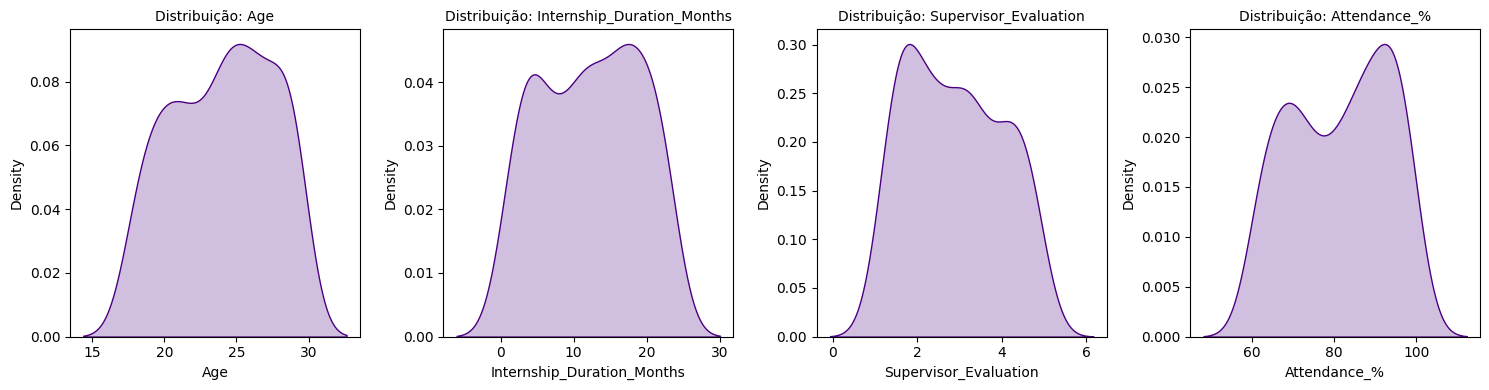

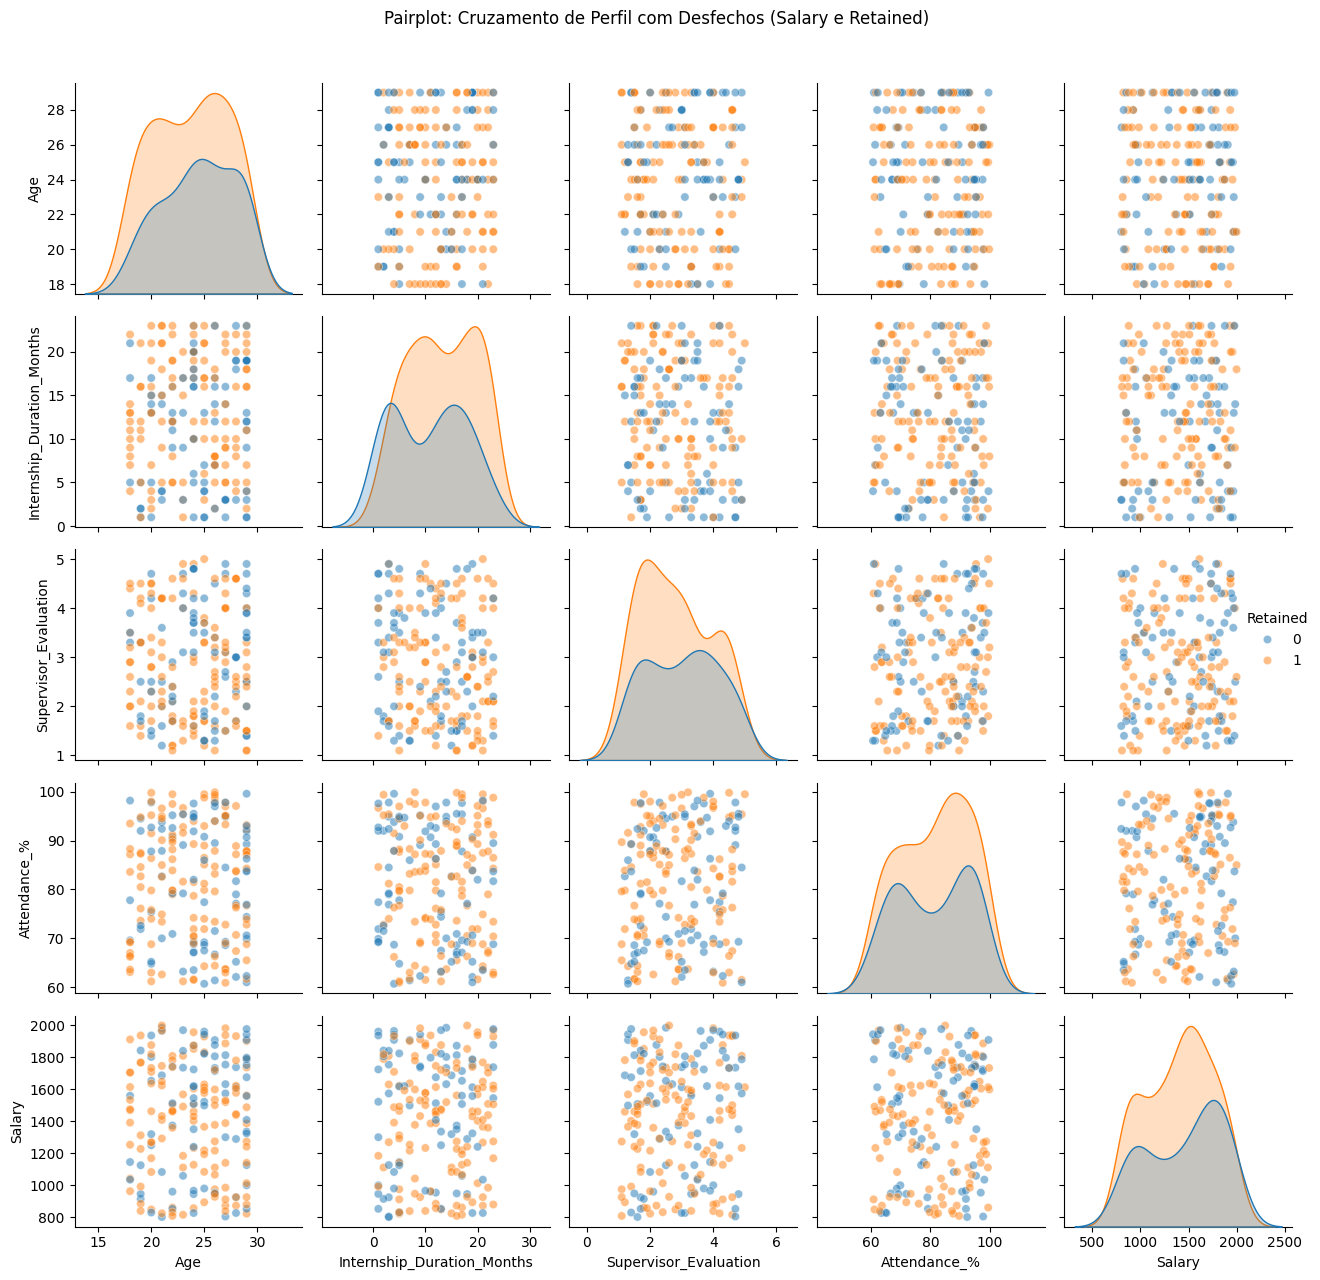

In [2]:
# Identificar variáveis de PERFIL (Features de treino para o Cluster)
# Removemos ID (ruído), Retained (desfecho binário) e Salary (alvo de análise posterior)
cols_perfil = df_raw.select_dtypes(include=['number']).drop(columns=['Intern_ID', 'Retained', 'Salary'], errors='ignore').columns

# Visualização de Densidade (KDE) - Apenas para as variáveis que definirão os grupos
plt.figure(figsize=(15, 4))
for i, col in enumerate(cols_perfil):
    plt.subplot(1, len(cols_perfil), i+1)
    sns.kdeplot(df_raw[col], fill=True, color='indigo')
    plt.title(f'Distribuição: {col}', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "numerical_variables_distribution.png", bbox_inches="tight")
plt.show()

# Pairplot: Validação Visual
# Usamos o perfil + as duas variáveis de análise à posteriori (Salary e Retained).
cols_visualizacao = list(cols_perfil) + ['Salary', 'Retained']

sns.pairplot(df_raw[cols_visualizacao], hue='Retained', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot: Cruzamento de Perfil com Desfechos (Salary e Retained)', y=1.02)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "pairplot_numerical_variables_retention.png", bbox_inches="tight")
plt.show()

## Insights da Análise Exploratória (Data Understanding)

A inspeção visual das distribuições e cruzamentos fundamenta a estratégia de **Clustering**:

- **Multi-modalidade**  
  Variáveis como `Attendance_%` e `Internship_Duration` apresentam múltiplos picos de densidade.  
  - Indica que os estagiários não formam um grupo uniforme.  
  - Existência de grupos naturais (ex: perfis muito assíduos vs. não assíduos) que o algoritmo poderá isolar.

- **Sobreposição de Desfechos (Pairplot)**  
  - A dispersão das cores de `Retained` e a ausência de tendência clara no `Salary` mostram que os desfechos não dependem de uma única variável.  
  - O clustering torna-se necessário para descobrir combinações de fatores (perfis) que a análise linear ignora.

- **Independência das Features**  
  - A forma em "nuvem" dos pontos no pairplot indica baixa correlação linear.  
  - Cada variável (`Idade`, `Avaliação`, `Assiduidade`) aporta informação única e relevante para criar **Perfis distintos**.

---
# **Fase 3 - Data Preparation**

### Nesta iteração, optou-se por não incluir variáveis categóricas nominais (como Major ou Department) pelas seguintes razões:

- Incompatibilidade Métrica: O K-Means baseia-se em Distância Euclidiana. Calcular a distância entre 'Engenharia' e 'Marketing' não possui significado físico ou matemático num espaço contínuo, o que corromperia o cálculo dos centroides.

- Prevenção da Esparsidade (Curse of Dimensionality): O uso de One-Hot Encoding em variáveis com múltiplas categorias expandiria o espaço vetorial desnecessariamente. Em alta dimensionalidade, os pontos tendem a tornar-se equidistantes, degradando a densidade dos clusters.

- Foco no Comportamento Quantitativo: Para esta segmentação, priorizamos métricas de desempenho e assiduidade, tratando as categorias apenas como metadados para caracterizar os grupos a posteriori.
    - Se usassemos as categóricas via One-Hot Encoding, estariamos a forçar o algoritmo a agrupar pessoas apenas porque pertencem ao mesmo departamento, o que muitas vezes mascara os padrões reais de comportamento.

# Scaling de Features

In [3]:
# 1. Isolamento de Features de Perfil
# Selecionamos apenas as variáveis que definem o comportamento/perfil para o treino
X_raw = df_raw[cols_perfil]

# 2. Padronização (StandardScaler)
# Essencial para K-Means: garante que variáveis com escalas diferentes (ex: Idade vs Horas) 
# tenham o mesmo peso no cálculo das distâncias euclidianas.
scaler = StandardScaler()

# 3. Transformação e Reconstrução do DataFrame
# Preservamos o index original para permitir o cruzamento posterior com Salary e Retained
X_prepared = pd.DataFrame(
    scaler.fit_transform(X_raw), 
    columns=cols_perfil, 
    index=df_raw.index
)

# 4. Verificação de Sanidade (Z-Score Check)
print("--- Check-up de Preparação (StandardScaler) ---")
print(f"Variáveis processadas: {list(X_prepared.columns)}")
print(f"Média Global (Alvo ≈ 0): {X_prepared.mean().mean():.4f}")
print(f"Desvio Padrão Global (Alvo ≈ 1): {X_prepared.std().mean():.4f}")

X_prepared.head()

--- Check-up de Preparação (StandardScaler) ---
Variáveis processadas: ['Age', 'Internship_Duration_Months', 'Supervisor_Evaluation', 'Attendance_%']
Média Global (Alvo ≈ 0): -0.0000
Desvio Padrão Global (Alvo ≈ 1): 1.0025


,Age,Internship_Duration_Months,Supervisor_Evaluation,Attendance_%
0,-0.002874,1.147976,-0.971730,-0.797971
1,-0.864960,0.407824,-1.508350,0.110487
2,1.146575,-1.368542,-1.061167,-0.200744
3,0.284489,1.592068,-0.703420,0.430130
4,-0.577598,-0.628389,-1.061167,1.355411


### **Síntese da Fase 3: Data Preparation**

A preparação dos dados para o Clustering foi orientada por dois princípios de rigor analítico:

1.  **Isolamento de Variáveis de Perfil (Feature Selection):** As colunas `Salary` e `Retained` foram removidas do treino. Esta decisão estratégica garante que o algoritmo agrupe estagiários puramente pelo seu mérito e comportamento (Idade, Avaliação, Assiduidade). O objetivo é criar "Personas" imparciais para, posteriormente, avaliar se a remuneração e a retenção da empresa são coerentes com estes perfis.
2.  **Scaling:** Sendo o K-Means um algoritmo baseado em Distância Euclidiana, a aplicação do `StandardScaler` ($\mu=0, \sigma=1$) foi obrigatória. Este passo assegura que variáveis com amplitudes maiores (ex: Age) não dominem matematicamente variáveis com intervalos menores (ex: Supervisor_Evaluation), garantindo peso igual a todas as dimensões do perfil.


<hr>

# **Fase 4 - Modeling & Evaluation**

### Nesta fase, aplicamos o algoritmo K-Means para segmentar o dataset. O desafio central do clustering não é apenas agrupar, mas encontrar o "número natural" de perfis que equilibre a precisão matemática com a interpretabilidade para os RH.

**Objetivos Técnicos da Iteração**

- Heurística do Cotovelo: Identificar o ponto onde o ganho de coesão interna (Inércia) deixa de compensar o aumento da complexidade do modelo.

- Otimização da Inicialização: Utilização do k-means++ para evitar ótimos locais e garantir que os centroides iniciais sejam estrategicamente posicionados.

- Definição do K-Ideal: Cruzar a métrica matemática com a lógica de negócio (ter 20 clusters pode ser exato, mas é impossível de gerir operacionalmente).
    
    - Para determinar o número ideal de perfis ($K$), analisamos duas métricas complementares:
        1) Inércia (Método do Cotovelo)
        2) Silhouette Score

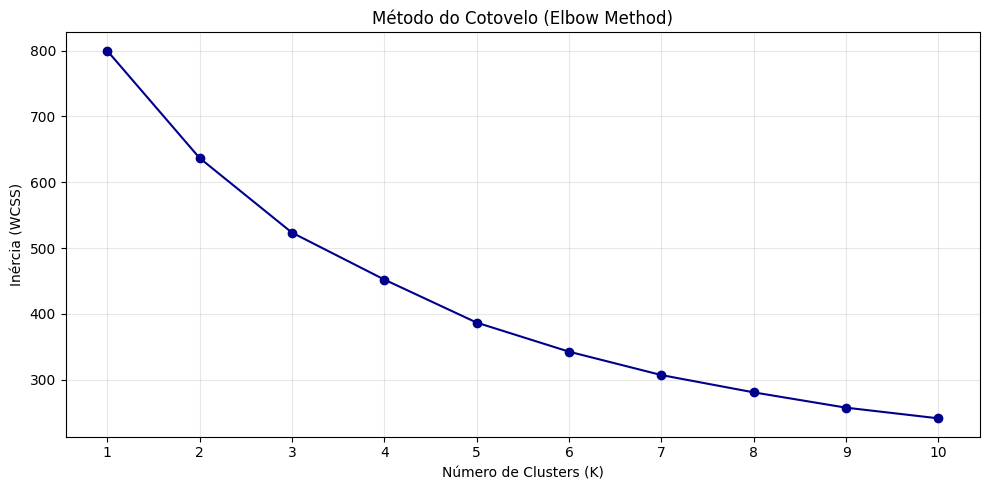

In [4]:
# 1. Testar diferentes números de clusters (de 1 a 10)
wcss = [] # Within-Cluster Sum of Squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_prepared)
    wcss.append(kmeans.inertia_)

# 2. Visualização do Gráfico do Cotovelo
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', color='darkblue')
plt.title('Método do Cotovelo (Elbow Method)')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (WCSS)')
plt.xticks(range(1, 11))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "elbow_method_clusters.png", bbox_inches="tight")
plt.show()

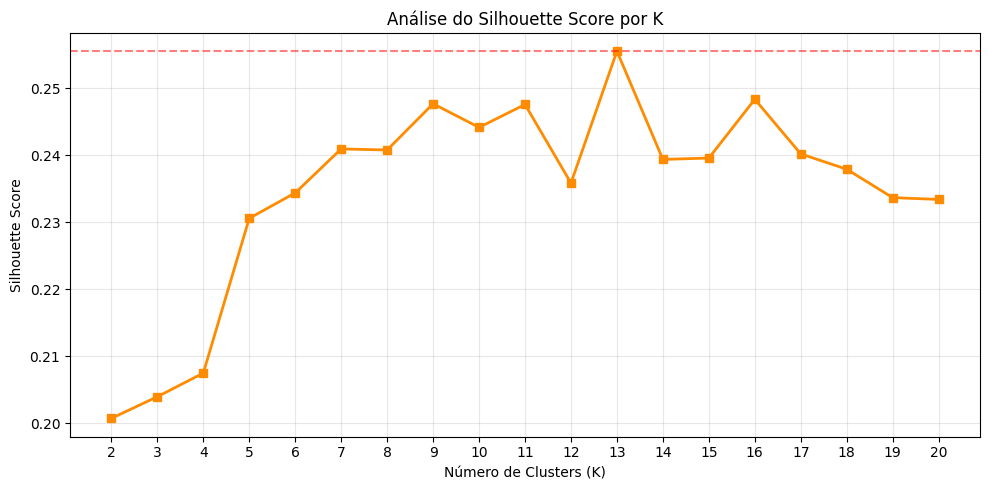

In [5]:
# 1. Calcular Silhouette Scores para K de 2 a 20
sil_scores = []
k_range = range(2, 21)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_prepared)
    sil_scores.append(silhouette_score(X_prepared, labels))

# 2. Visualização
plt.figure(figsize=(10, 5))
plt.plot(k_range, sil_scores, marker='s', color='darkorange', linewidth=2)
plt.title('Análise do Silhouette Score por K')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.axhline(max(sil_scores), color='red', linestyle='--', alpha=0.5) # Linha no pico

plt.tight_layout()
plt.savefig(FIGURES_DIR / "silhouette_score_clusters.png", bbox_inches="tight")
plt.show()

## Decisão na Escolha do K

### 1. Métricas Utilizadas
Para determinar o número ideal de perfis ($K$), foram analisadas duas métricas complementares:

- **Inércia (Método do Cotovelo):**  
  Mede a coesão interna dos clusters. Quanto menor o valor, mais próximos estão os pontos dos seus centróides. Esta métrica tende a diminuir continuamente à medida que aumentamos $K$.

- **Silhouette Score:**  
  Avalia simultaneamente a coesão interna (proximidade interna)  e a separação entre clusters (distância entre grupos). Os valores variam entre -1 e 1, sendo que valores mais elevados indicam uma melhor definição dos grupos.

### 2. Resultados da Análise

A análise conjunta das métricas revela um comportamento típico em dados de alta fidelidade:

- **Ótimo Matemático ($K=13$):**  
  O Silhouette Score atinge o seu valor máximo próximo de 13 clusters, indicando a existência de micro-segmentos bem definidos e geometricamente separados.

- **Ótimo Estrutural ($K=3$ ou $K=4$):**  
  O Método do Cotovelo evidencia que a maior redução de inércia ocorre até $K=4$. A partir deste ponto, os ganhos tornam-se marginais, caracterizando uma zona de rendimentos decrescentes.

### 3. Decisão Final

#### Generalização vs. Fragmentação

Apesar da evidência matemática apontar para $K=13$, a decisão recai sobre $K=4$.

**Justificação:**  
No contexto de Recursos Humanos, o objetivo principal é garantir aplicabilidade estratégica. A criação de 13 clusters conduziria a uma segmentação excessivamente granular, dificultando a operacionalização de políticas diferenciadas.

Ao optar por $K=4$, asseguramos:
- Perfis suficientemente distintos (validade analítica)
- Segmentação interpretável (clareza conceptual)
- Aplicabilidade prática (viabilidade operacional)

### 4. Conclusão

A escolha de $K=4$ representa um compromisso equilibrado entre rigor analítico e utilidade prática, permitindo a definição de macro-perfis robustos e acionáveis.

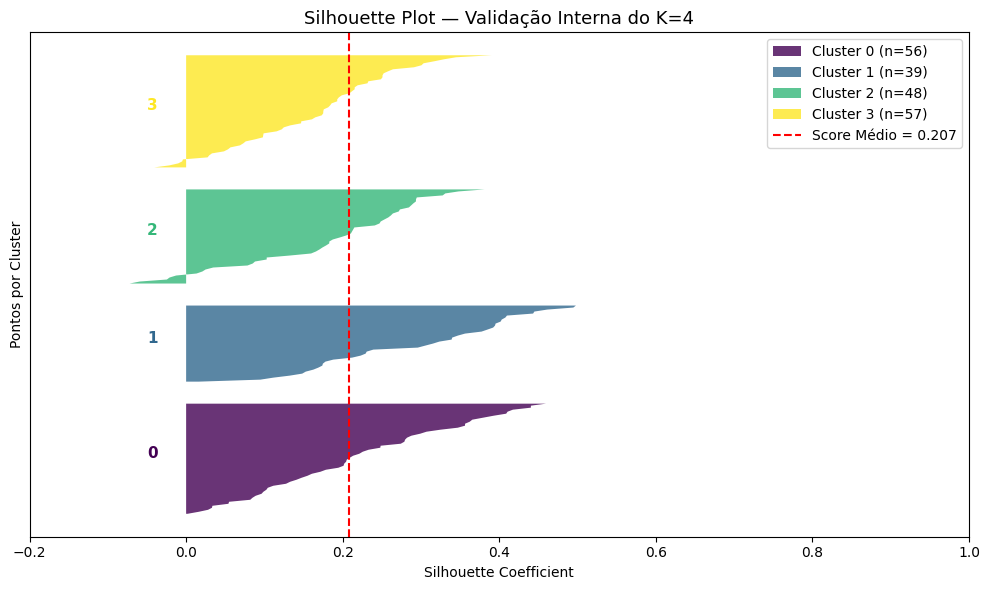

In [23]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(10, 6))

# Calcular silhouette por ponto
kmeans_4_sil = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
labels_4 = kmeans_4_sil.fit_predict(X_prepared)
sil_values = silhouette_samples(X_prepared, labels_4)

colors = ['#440154', '#31688e', '#35b779', '#fde725']
y_lower = 10
for i in range(4):
    cluster_sil = np.sort(sil_values[labels_4 == i])
    size = cluster_sil.shape[0]
    y_upper = y_lower + size

    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, cluster_sil,
                     facecolor=colors[i], alpha=0.8, label=f'Cluster {i} (n={size})')
    ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=11, color=colors[i], fontweight='bold')
    y_lower = y_upper + 10

avg_score = silhouette_score(X_prepared, labels_4)
ax.axvline(x=avg_score, color="red", linestyle="--", label=f'Score Médio = {avg_score:.3f}')

ax.set_title('Silhouette Plot — Validação Interna do K=4', fontsize=13)
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Pontos por Cluster')
ax.set_yticks([])
ax.set_xlim([-0.2, 1])
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "silhouette_plot_k4.png", bbox_inches="tight")
plt.show()

### Validação Interna — Silhouette Plot (K=4)

O Silhouette Plot confirma a solidez da decisão de K=4 num contexto de dados comportamentais humanos.

- **Score Médio = 0.207:** Valor esperado em dados de RH, onde os perfis humanos raramente formam grupos geometricamente puros. Não invalida a segmentação — contextualiza-a.
- **Clusters 0 e 1** apresentam maior coesão interna, reforçando a validade das análises de Salary e Retained efetuadas a posteriori.
- **Clusters 2 e 3** exibem maior sobreposição geométrica, o que é em si um insight de negócio: estes estagiários têm perfis de transição e risco, sem enquadramento claro numa única categoria.

> A instabilidade matemática dos Clusters 2 e 3 é coerente com a sua caracterização comportamental 
— são precisamente os perfis que requerem maior intervenção por parte dos RH.

## Resumo das 3 métricas
## As 3 métricas são respostas a perguntas diferentes

| Métrica               | Pergunta que responde                                                  | O que mede              | Output                    |
|----------------------|------------------------------------------------------------------------|--------------------------|---------------------------|
| Elbow (Inércia)      | "A partir de que K deixa de compensar adicionar mais grupos?"          | Compactação interna      | Gráfico de curva          |
| Silhouette por K     | "Qual o K onde os grupos são mais distintos entre si?"                 | Coesão + Separação       | Gráfico de linha por K    |
| Silhouette Plot      | "O K escolhido é internamente sólido?"                                 | Qualidade ponto a ponto  | Gráfico de facas          |

---

## A ordem lógica correta é exactamente a que usaste

**Elbow → Silhouette por K → Silhouette Plot**

---

## Porquê?

1. **Elbow** — visão macro, elimina K's claramente maus.  
   Diz: *"para além de K=4 não compensa"*

2. **Silhouette por K** — afina a decisão com mais rigor.  
   Diz: *"matematicamente K=13 é o melhor"*

3. **Silhouette Plot** — valida o K que escolheste.  
   Diz: *"o meu K=4 tem clusters sólidos ou problemáticos?"*

---

É um funil: do geral para o específico.  
Não faz sentido inverter — o Plot pressupõe que já escolheste um K.

In [7]:
# Criar cópias para não alterar o dataset original durante este teste
df_testes = df_raw.copy()

# Treinar modelo para K=4
kmeans_4 = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
df_testes['Cluster_K4'] = kmeans_4.fit_predict(X_prepared)

# Variáveis que queremos observar para definir o perfil
cols_perfil = ['Age', 'Internship_Duration_Months', 'Supervisor_Evaluation', 'Attendance_%']

# Gerar as tabelas de médias (Os Perfis)
print("\n--- Perfis Médios para K=4 ---")
display(df_testes.groupby('Cluster_K4')[cols_perfil].mean().round(2))

# Ver o tamanho de cada grupo em K=4 para verificar se há "micro-grupos" (overfitting)
print("\n--- Tamanho dos grupos em K=4 ---")
print(df_testes['Cluster_K4'].value_counts())


--- Perfis Médios para K=4 ---


,Age,Internship_Duration_Months,Supervisor_Evaluation,Attendance_%
Cluster_K4,,,,
0,24.61,16.98,2.21,89.50
1,24.97,8.00,4.17,91.63
2,19.56,10.73,2.84,77.66
3,26.51,11.77,2.71,69.55



--- Tamanho dos grupos em K=4 ---
Cluster_K4
3    57
0    56
2    48
1    39
Name: count, dtype: int64


---

## Cluster 0: Estagiários de Longo Prazo com Desempenho Estável
**Perfil:** Idade intermédia (24.6) com o maior tempo de permanência na empresa (17 meses).  
**Análise:** Apresenta uma assiduidade elevada (90%), compensando uma avaliação de supervisão modesta (2.21). É um perfil de estabilidade operacional, sugerindo uma curva de aprendizagem longa ou estagnação técnica que requer intervenção pedagógica.

---

## Cluster 1: Jovens de Alto Potencial e Performance
**Perfil:** Grupo mais jovem (19.6 anos) com avaliações de excelência (4.17) e assiduidade de topo (92%).  
**Análise:** Representa o segmento de Alto Potencial (HiPo). Apesar da curta duração de estágio (8 meses), demonstra uma adaptação e entrega superiores. Dada a reduzida dimensão do grupo ($n=39$), este é o cluster crítico para políticas de retenção imediata e aceleração de carreira.

---

## Cluster 2: Estagiários Juniores com Baixa Assiduidade
**Perfil:** O grupo mais jovem (19.6 anos) com a menor duração de estágio (11 meses).  
**Análise:** Exibe métricas equilibradas, mas com a menor assiduidade do dataset (78%). Reflete um perfil ainda em fase de aculturação ou com dificuldades de conciliação, necessitando de maior acompanhamento de mentoria para evitar o turnover precoce.

---

## Cluster 3: Perfil Sénior com Indicadores de Risco
**Perfil:** Grupo com a média de idade mais elevada (26.5 anos).  
**Análise:** Apesar da maturidade etária, apresenta baixos índices de assiduidade (70%) e avaliações de desempenho reduzidas (2.71). Este padrão sugere desmotivação ou desajuste entre as expectativas do estagiário e a função, sendo o principal alvo para análise de causas de saída.
<br>

---

# Gráficos de Visualização dos Clusters

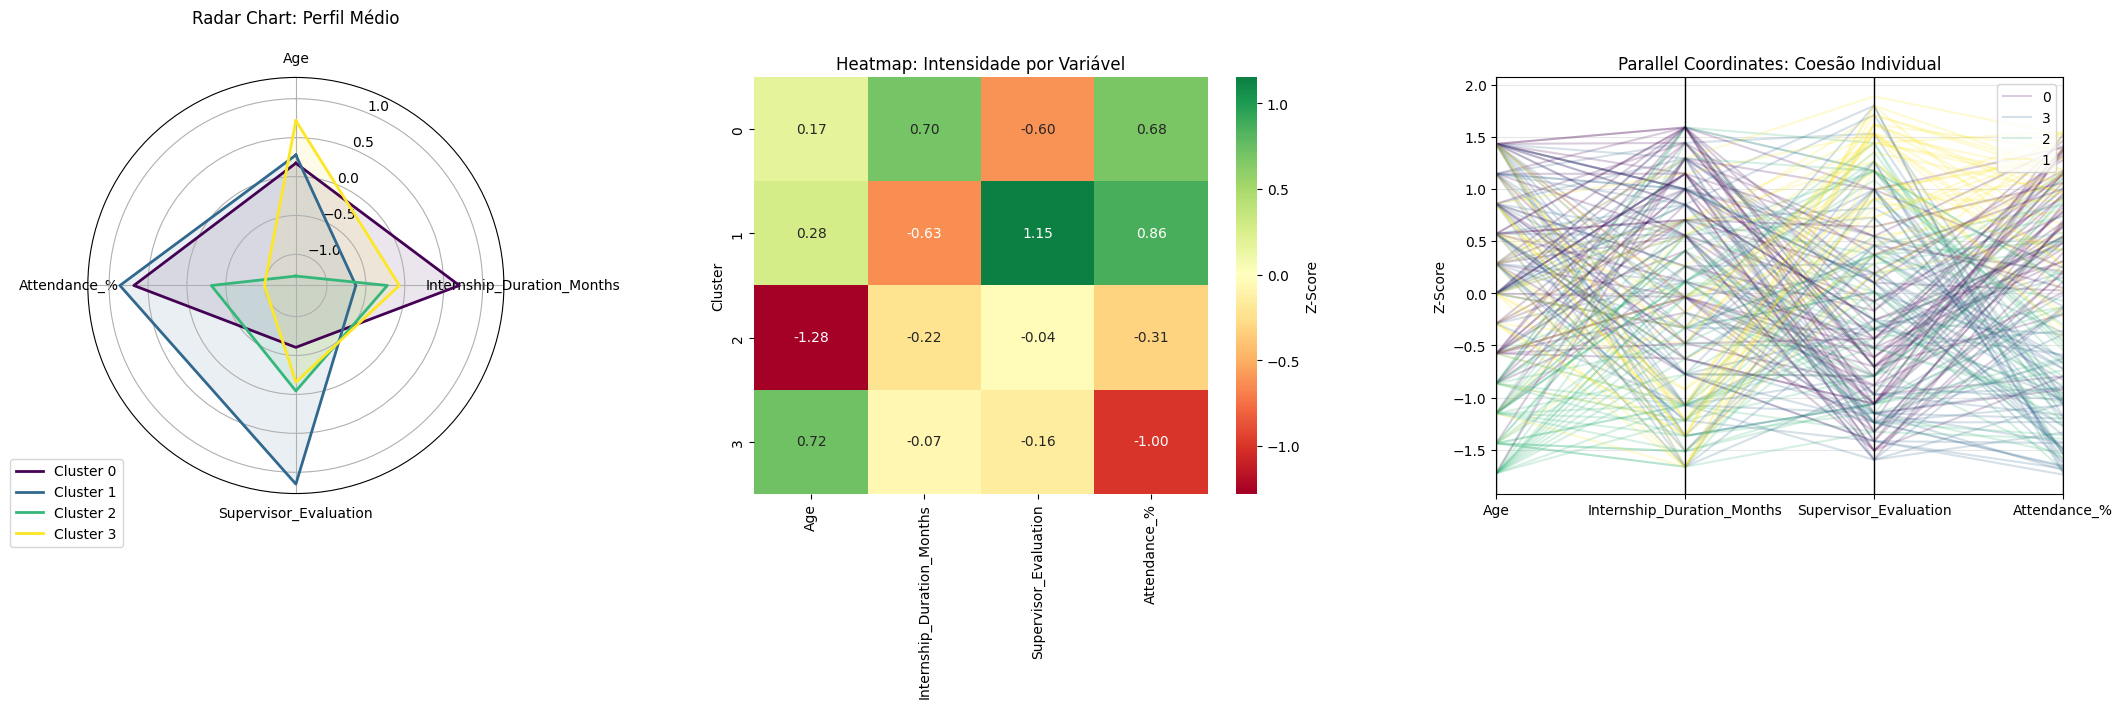

In [8]:
# 1. Preparação dos dados (Z-Score)
X_viz = X_prepared.copy()
X_viz['Cluster'] = df_testes['Cluster_K4']
cluster_means = X_viz.groupby('Cluster').mean()

# 2. Configuração da Figura (1 linha, 3 colunas)
fig = plt.figure(figsize=(22, 7))
colors = ['#440154', '#31688e', '#35b779', '#fde725'] # Paleta Viridis

# --- SUBPLOT 1: Radar Chart ---
ax1 = fig.add_subplot(131, polar=True)
features = list(X_prepared.columns)
angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]

for i, (idx, row) in enumerate(cluster_means.iterrows()):
    values = row.values.flatten().tolist()
    values += values[:1]
    ax1.plot(angles, values, linewidth=2, label=f'Cluster {int(idx)}', color=colors[i])
    ax1.fill(angles, values, alpha=0.1, color=colors[i])

ax1.set_theta_offset(np.pi / 2)
ax1.set_theta_direction(-1)
ax1.set_thetagrids(np.degrees(angles[:-1]), features)
ax1.set_title("Radar Chart: Perfil Médio", pad=20)
ax1.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

# --- SUBPLOT 2: Heatmap ---
ax2 = fig.add_subplot(132)
sns.heatmap(cluster_means, annot=True, cmap='RdYlGn', center=0, fmt='.2f', ax=ax2, cbar_kws={'label': 'Z-Score'})
ax2.set_title("Heatmap: Intensidade por Variável")
ax2.set_ylabel("Cluster")

# --- SUBPLOT 3: Parallel Coordinates ---
ax3 = fig.add_subplot(133)
parallel_coordinates(X_viz, 'Cluster', color=colors, alpha=0.2, ax=ax3)
ax3.set_title("Parallel Coordinates: Coesão Individual")
ax3.set_ylabel("Z-Score")
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "cluster_profiles_analysis.png", bbox_inches="tight")
plt.show()

In [9]:
# 1. PCA para 3 componentes
pca_3d = PCA(n_components=3, random_state=42)
components_3d = pca_3d.fit_transform(X_prepared)

# 2. DataFrame para visualização
df_pca_3d = pd.DataFrame(components_3d, columns=['PC1', 'PC2', 'PC3'])
df_pca_3d['Cluster'] = df_testes['Cluster_K4'].astype(str)

# 3. Gráfico 3D melhorado
fig = px.scatter_3d(
    df_pca_3d,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Cluster',
    title='Visualização 3D dos Clusters (K=4)',
    labels={'PC1': 'Comp. 1', 'PC2': 'Comp. 2', 'PC3': 'Comp. 3'},
    opacity=0.75,
    color_discrete_sequence=px.colors.qualitative.Vivid
)

fig.update_traces(marker=dict(size=5))

fig.update_layout(
    width=1000,
    height=700,
    margin=dict(l=20, r=20, t=60, b=20),
    legend_title_text='Cluster',
    scene=dict(
        xaxis_title='Comp. 1',
        yaxis_title='Comp. 2',
        zaxis_title='Comp. 3',
        aspectmode='cube',
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))
    )
)

fig.write_html(FIGURES_DIR / "clusters_3d_pca.html")
fig.show()

In [10]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_prepared)

# Variância explicada por componente
print("Variância por componente:", pca.explained_variance_ratio_)

# Variância total explicada (o mais importante)
print("Variância total explicada:", pca.explained_variance_ratio_.sum())

Variância por componente: [0.29861507 0.25083296 0.23029441]
Variância total explicada: 0.779742444833744


#### **Interpretação da Visualização PCA 3D**

- A redução dimensional com PCA para 3 componentes permitiu preservar cerca de 78% da variância total dos dados, indicando uma representação bastante fiel da estrutura original.

- Dado que o dataset possui apenas 4 variáveis, esta redução implica a remoção de apenas uma dimensão, o que justifica a elevada variância explicada.

- A distribuição da variância pelos três componentes é equilibrada, sugerindo que os clusters resultam da combinação de várias variáveis e não de uma única dimensão dominante.

- A visualização 3D é adequada para análise exploratória e permite identificar padrões gerais de segmentação, embora não represente a totalidade da informação (≈22% não está capturada).

<br>

<hr>

### **Etapa final**

Nesta etapa final, procedemos ao cruzamento dos perfis comportamentais identificados ($K=4$) com as variáveis de desfecho que foram deliberadamente isoladas da fase de treino: Salary (Remuneração) e Retained (Retenção).

**Pontos a verificar:**

- Validação de Mérito: Verificar se os segmentos de performance superior (Cluster 1) estão a ser devidamente valorizados pela política salarial da organização.

- Análise de Fidelização: Identificar qual o perfil de estagiário que apresenta maior taxa de permanência e se esta está correlacionada com o investimento financeiro.

- Deteção de Ineficiências: Expor eventuais discrepâncias onde perfis de baixo desempenho ou risco (Cluster 3) possam estar a captar recursos (salário) sem o correspondente retorno em retenção ou indicadores de performance (ex: avaliação e assiduidade).

C:\Users\Pedro\AppData\Local\Temp\ipykernel_24472\4049964580.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=analise_stats.index, y='Salary', data=analise_stats, palette=colors, ax=ax1)


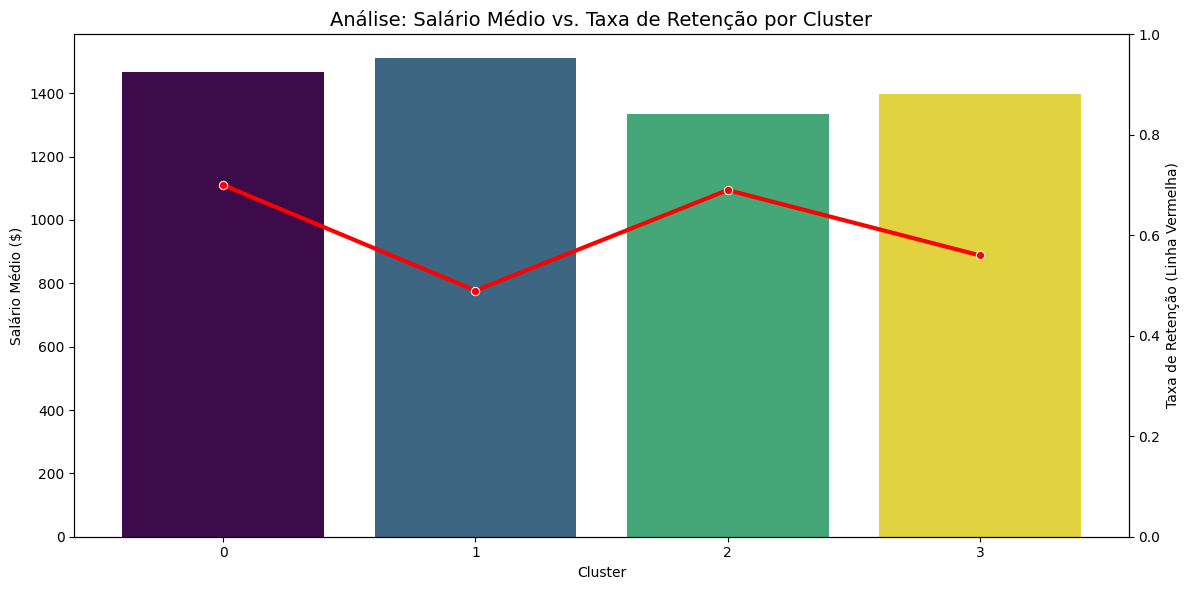

,Salary,Retained,Retained_%
Cluster,,,
0,1468.61,0.70,70.0%
1,1510.44,0.49,49.0%
2,1334.29,0.69,69.0%
3,1398.86,0.56,56.00000000000001%


In [11]:
# 1. Preparação da Tabela de Análise
# Recuperamos as variáveis originais de Salary e Retained
df_analise = df_raw[['Salary', 'Retained']].copy()
df_analise['Cluster'] = df_testes['Cluster_K4']

# 2. Cálculo das Médias de Análise por Cluster
analise_stats = df_analise.groupby('Cluster').agg({
    'Salary': 'mean',
    'Retained': 'mean' # Taxa de retenção (0 a 1)
}).round(2)

# Converter Retained para percentagem para facilitar a leitura
analise_stats['Retained_%'] = (analise_stats['Retained'] * 100).astype(str) + '%'

# 3. Visualização Comparativa
fig, ax1 = plt.subplots(figsize=(12, 6))

# Gráfico de Barras para Salário
sns.barplot(x=analise_stats.index, y='Salary', data=analise_stats, palette=colors, ax=ax1)
ax1.set_title('Análise: Salário Médio vs. Taxa de Retenção por Cluster', fontsize=14)
ax1.set_ylabel('Salário Médio ($)')

# Eixo secundário para a Retenção
ax2 = ax1.twinx()
sns.lineplot(x=analise_stats.index, y='Retained', data=analise_stats, color='red', marker='o', linewidth=3, ax=ax2)
ax2.set_ylabel('Taxa de Retenção (Linha Vermelha)')
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "salary_retention_by_cluster.png", bbox_inches="tight")
plt.show()

display(analise_stats)

# Síntese Final

Este projeto teve como objetivo caracterizar o perfil comportamental dos estagiários e avaliar a eficácia das políticas de retenção de talento.  
Através da segmentação multidimensional (K = 4) e subsequente analise financeira, foram extraídas as seguintes conclusões operacionais:

---

## 1. Caracterização dos Perfis (K = 4)

Superando a análise redutora do *"estagiário médio"*, identificaram-se quatro segmentos comportamentais distintos:

- **Cluster 0:** Base operacional estável e resiliente  
- **Cluster 1:** Jovens talentos de alta performance (nicho de excelência)  
- **Cluster 2:** Perfis juniores em adaptação, com défices de assiduidade  
- **Cluster 3:** Perfis seniores com baixo rendimento e desajuste funcional  

---

## 2. Análise às Políticas de Retenção e Remuneração

O cruzamento dos perfis com métricas contratuais evidenciou indícios de ineficiência na estratégia atual de Recursos Humanos:

### Paradoxo do Talento
- O **Cluster 1** apresenta a taxa de retenção mais baixa da organização (< 60%)  
- Apesar de remuneração ligeiramente superior, esta é insuficiente para fidelização  
- A empresa atua, na prática, como plataforma de formação para a concorrência  

---

### Privilégio da Estabilidade
- O **Cluster 0** apresenta as taxas de retenção mais elevadas  
- Forte capacidade de retenção de perfis consistentes  
- Fraca capacidade de retenção de talento de excelência

<br>

Não se observa uma relação direta entre níveis salariais e retenção, sugerindo que fatores comportamentais e de alinhamento organizacional têm maior peso.
<br>

---

## 3. Recomendações Estratégicas

Para maximizar o valor gerado pelo programa de estágios, propõem-se três eixos de intervenção:

### Aceleração de Carreira (Cluster 1)
- Implementar programas de progressão acelerada (fast-track)  
- Rever salários de forma competitiva  
- Foco na retenção de estagiários com desempenho de topo  

---

### Mentoria de Integração (Cluster 2)
- Criar acompanhamento estruturado e contínuo  
- Reduzir falhas de assiduidade  
- Promover evolução para Cluster 0 ou Cluster 1  

---

### Revisão do Recrutamento (Cluster 3)
- Rever critérios de seleção  
- Alinhar expectativas entre empresa e candidatos  
- Reduzir o desajuste funcional observado  

---

## 4. Conclusão Final

A estratégia atual de Gestão de Talento evidencia um desequilíbrio estrutural:

- É eficaz na retenção de estabilidade operacional  
- É ineficaz na retenção de alto desempenho  

A transição estratégica deve evoluir de um modelo de retenção por volume para uma abordagem centrada na retenção de valor acrescentado.

<hr>

# FASE 6: Deployment

In [12]:
# 1. Gerar o dataset final consolidado
# Incluímos as variáveis originais, os dados preparados e o cluster atribuído
df_entrega_final = df_raw.copy()
df_entrega_final['Cluster_Perfil'] = df_testes['Cluster_K4']

# 2. Exportar para Excel/CSV para a equipa de RH
# Este ficheiro é o "produto final" que será entregue ao negócio
try:
    output_path = DATA_DIR / "Segmentacao_Estagiarios_Final.csv"
    
    df_entrega_final.to_csv(
        output_path,
        index=False,
        sep=';',
        encoding='utf-8-sig'
    )
    
    print(f"✅ Sucesso: Ficheiro '{output_path.name}' gerado em: {output_path}")
    
except Exception as e:
    print(f"❌ Erro na exportação: {e}")

# 3. Sumário de Controlo (Check-sum)
print(f"\nResumo da Entrega:")
print(f"- Total de estagiários segmentados: {len(df_entrega_final)}")
print(f"- Número de perfis identificados: {df_entrega_final['Cluster_Perfil'].nunique()}")

✅ Sucesso: Ficheiro 'Segmentacao_Estagiarios_Final.csv' gerado em: C:\CA_2025-09_AiDAPT02\C12_PythonDataAnalysis\Projeto_Final\CA_AiDAPT01_P1_02_Grupo02\CA_AiDAPT01_P1_02_Grupo02\03_crisp_clustering\data\Segmentacao_Estagiarios_Final.csv

Resumo da Entrega:
- Total de estagiários segmentados: 200
- Número de perfis identificados: 4
